# Does replaying the same movie clip reduce the variability of resting-state fMRI?

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

#Define filtering parameters
metric = "correlation"
atlas_dimension = "64"
fd_threshold = 0.4
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-derivatives-rsmovie/functional_connectivity/")
dataset_path = Path("/data/datasets/hcph-dataset")
#save_path = code_path / "docs/assets/images"
save_path = Path("/data/derivatives/hcph-suppl/")

## Load the functional connectivity matrices

Configuration 'hcph' already exists, skipping add_config_paths.
(2080, 2)


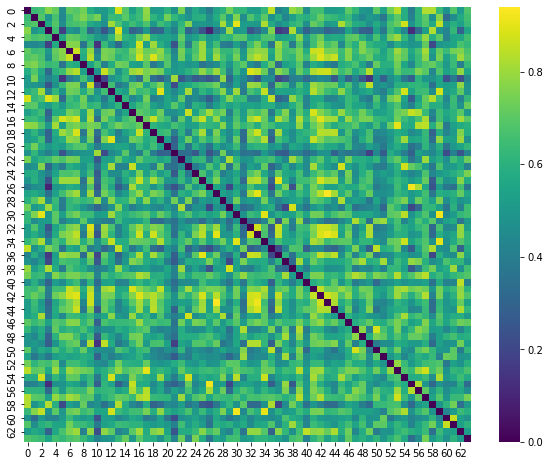

In [34]:
# Initialize the BIDS layout, we use a custom indexer because we are using entities that are not yet officially recognized by BIDS 
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration 'hcph' already exists" in str(e):
        print("Configuration 'hcph' already exists, skipping add_config_paths.")
    else:
        raise e
_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)
save_layout = BIDSLayout(save_path, config="hcph", indexer=_indexer, validate=False)

# Get all the files matching the pattern
entities_base = {
    'subject': '001',
    'task': 'rsmovie',
    'measure': metric,
    'scale': atlas_dimension,
    'fd_threshold': fdthresh_str,
}
files = layout.get(**entities_base, suffix='connectivity', extension='.tsv', return_type='file')
#assert len(files) == 36, f"Expected 36 FC matrices, got {len(files)}"

# Load the data from each file and concatenate
# Keep only upper-triangle since the FC matrix is symmetric (does the diagonal of our FC contain only ones ? if yes can discard the diagonal, if not have to keep it 
fc_matrices = []
for file in files:
    fc_matrix = pd.read_csv(file, sep='\t', header=None)
    fc_matrices.append(fc_matrix.values[np.triu_indices_from(fc_matrix, k=0)])

# Store the matrix size for reconstruction later
fc_size = fc_matrix.shape[0]
# Concatenate all the upper triangle values
fc_concat = np.vstack(fc_matrices)
# Transport matrix
fc_concat = fc_concat.T

#Plot an example FC matrix
plt.figure(figsize=(10, 8))
sns.heatmap(fc_matrix, cmap='viridis')

# Generate a random matrix of size 2080x36
#fc_concat = np.random.rand(2080, 36)
print(fc_concat.shape)

In [35]:
# Add the information that apply too all figures generated below to the base entities
entities_base["experiment"] = "fmrivar"
entities_base["extension"] = ".svg"
entities_base["datatype"] = "figures"
entities_base["suffix"] = "bold"

(2, 2)


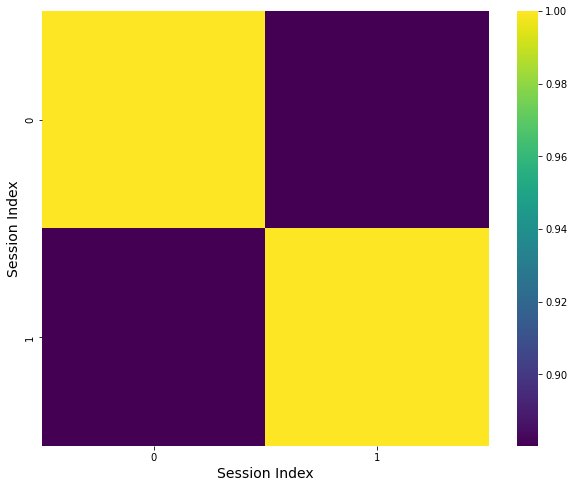

Overall mean correlation: 0.9401739783076779


In [36]:
# Entities specific to this plot
entities = {'visualization': 'similmat'}
entities.update(entities_base)

similarity_matrix = np.corrcoef(fc_concat, rowvar=False)
print(similarity_matrix.shape)
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='viridis')
plt.xlabel('Session Index', fontsize=14)
plt.ylabel('Session Index', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

mean_corr = np.mean(similarity_matrix)
print(f"Overall mean correlation: {mean_corr}")

## Run PCA to estimate the residual variance for each rsfMRI run

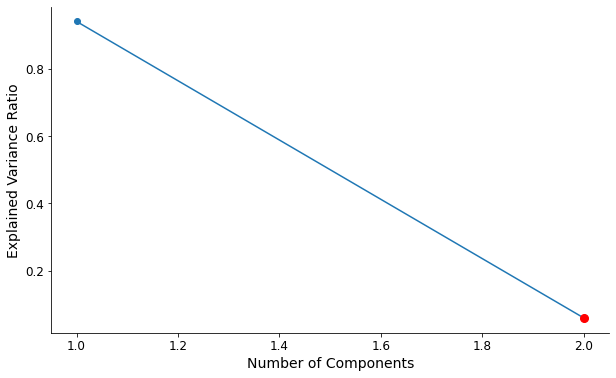

In [37]:
from sklearn.decomposition import PCA
# Entities specific to this plot
entities = {'visualization': 'explainedvar'}
entities.update(entities_base)

# Run PCA
# Center the data by removing the mean from each session
fc_concat = fc_concat - np.mean(fc_concat, axis=0)

# Standardize the data to have unit variance
fc_concat = fc_concat / np.std(fc_concat, axis=0)

# Run PCA
pca = PCA()
pca.fit(fc_concat)

# Calculate the explained variance
explained_variance = pca.explained_variance_ratio_

# Generate the elbow plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-')
ax.set_xlabel('Number of Components', fontsize=14)
ax.set_ylabel('Explained Variance Ratio', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#Define the number of components to keep
n_comp = 2

# Highlight the points corresponding to number of components we keep in red
ax.plot(n_comp, explained_variance[n_comp-1], marker='o', markersize=8, color='red')
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

We are using the elbow plot to decide the number of principal components to keep.

## Reconstruct the FC with a limited number of components

After extracting the principal components, each FC matrix can be expressed as a linear combinations of the principal components plus a residual matrix.

In [38]:
print(pca.components_.shape)
# Project PC components back into each FC subject space
fc_projected = pca.transform(fc_concat)[:, :n_comp]
print(fc_projected.shape)
fc_reconstructed = np.dot(fc_projected, pca.components_[:n_comp, :]) + np.mean(fc_concat, axis=0)
print(fc_reconstructed.shape)

(2, 2)
(2080, 2)
(2080, 2)


## Compute the residual matrix

In [39]:
# Calculate the residuals as the difference between the full and reconstructed FC matrices
residuals = fc_concat - fc_reconstructed
print(residuals.shape)

(2080, 2)


In [40]:
import numpy as np
from sklearn.decomposition import PCA

# Project the data onto the residual components (from n_comp + 1 onwards)
residuals_frompc = pca.transform(fc_concat)[:, n_comp:]

# Reconstruct the data using the residual components
residuals_frompc = np.dot(residuals_frompc, pca.components_[n_comp:, :]) + np.mean(fc_concat, axis=0)

# Print the shape of the reconstructed data
print(residuals_frompc.shape)

(2080, 2)


## Plot residual matrix

In [41]:
# Function to reconstruct the full matrix from the upper triangle
def reconstruct_full_matrix(upper_triangle, size):
    full_matrix = np.zeros((size, size))
    upper_indices = np.triu_indices(size)
    full_matrix[upper_indices] = upper_triangle
    full_matrix = full_matrix + full_matrix.T - np.diag(np.diag(full_matrix))
    return full_matrix

# Test my reconstruction function
upper_triangle = fc_matrix.values[np.triu_indices_from(fc_matrix, k=0)]
full_matrix = reconstruct_full_matrix(upper_triangle, fc_size)
full_matrix.shape
assert np.array_equal(full_matrix, fc_matrix.values)

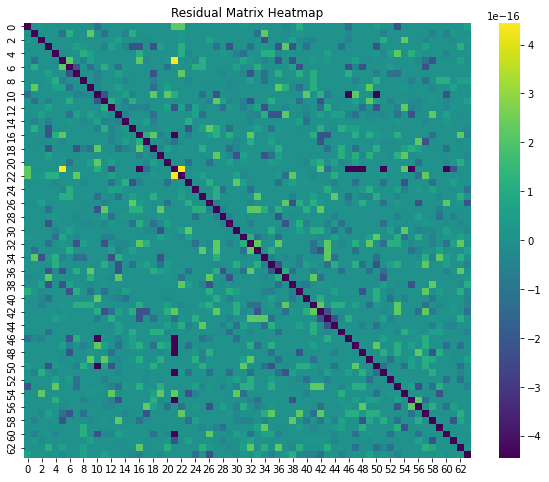

In [42]:
residual = reconstruct_full_matrix(residuals[:,0], fc_size)

# Plot the residual matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(residual, cmap='viridis')
plt.title('Residual Matrix Heatmap')
plt.show()

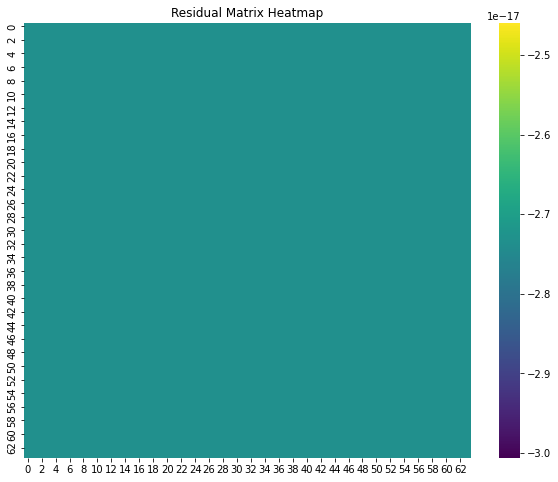

In [43]:
# Check whether reconstructing the residuals a different way leads to the same result
residual_frompc = reconstruct_full_matrix(residuals_frompc[:,0], fc_size)

# Plot the residual matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(residual_frompc, cmap='viridis')
plt.title('Residual Matrix Heatmap')
plt.show()

## Plot the variance of the residuals over sessions

In [44]:
def plot_res_variance(residuals, groupedby=False, min_res_var=0, max_res_var=1000):
    from scipy.optimize import curve_fit
    from sklearn.metrics import r2_score
    
    # Compute the variance of the residuals for each session
    residuals_var = np.var(residuals, axis=0)
    min_res_var = min(min_res_var, min(residuals_var))
    max_res_var = max(max_res_var, max(residuals_var))

    # Plot the variance of the residuals as a function of the session index
    plt.plot(range(len(residuals_var)), residuals_var, marker='o', linestyle='-', label='Variance of Residuals')

    # Fit and plot a negative exponential curve
    def neg_exp(x, a, b, c):
        return a * np.exp(-b * x) + c

    if residuals_var.shape[0] > 3:
        #popt, _ = curve_fit(neg_exp, range(len(residuals_var)), residuals_var, p0=(1, 0.01, 1))
        #neg_exp_r2 = r2_score(residuals_var, neg_exp(range(len(residuals_var)), *popt))
        #plt.plot(range(len(residuals_var)), neg_exp(range(len(residuals_var)), *popt), linestyle='--', label=f'Negative Exponential Fit (R$^2$={neg_exp_r2:.2f})')
        
        # Fit and plot a quadratic curve
        quadratic_model = np.poly1d(np.polyfit(range(len(residuals_var)), residuals_var, 2))
        quadratic_r2 = r2_score(residuals_var, quadratic_model(range(len(residuals_var))))
        plt.plot(range(len(residuals_var)), quadratic_model(range(len(residuals_var))), linestyle='--', label=f'Quadratic Fit (R$^2$={quadratic_r2:.2f})')

    # Fit and plot a linear curve
    linear_model = np.poly1d(np.polyfit(range(len(residuals_var)), residuals_var, 1))
    linear_r2 = r2_score(residuals_var, linear_model(range(len(residuals_var))))
    plt.plot(range(len(residuals_var)), linear_model(range(len(residuals_var))), linestyle='--', label=f'Linear Fit (R$^2$={linear_r2:.2f})')

    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    plt.legend()
    if groupedby:
        plt.title(groupedby, fontsize=16)
        
    return min_res_var, max_res_var
   

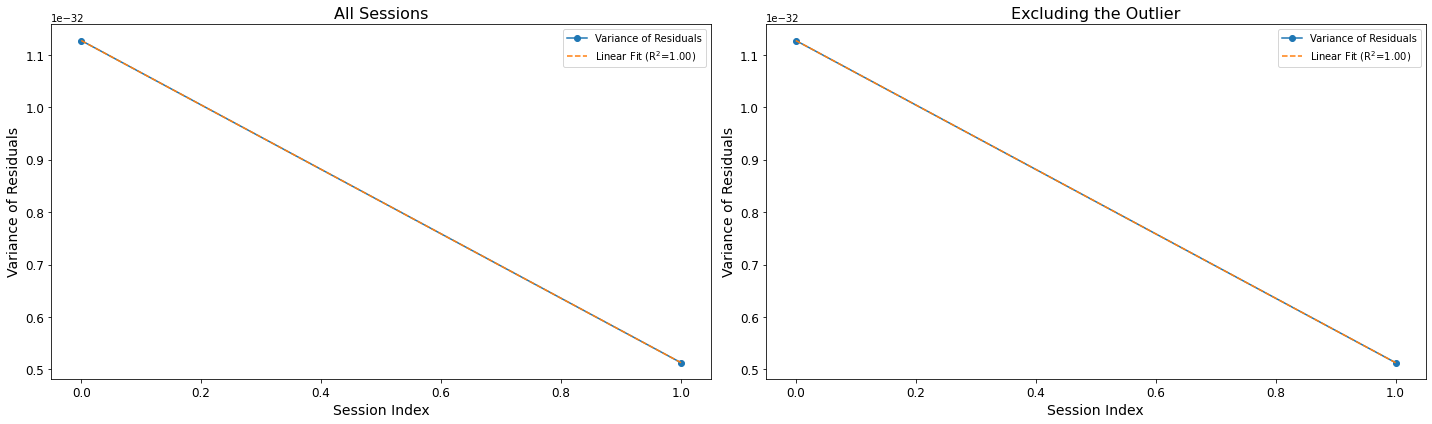

In [45]:
# Exclude 30th column
#residuals_wo_outlier = np.delete(residuals, 30, axis=1)

plt.figure(figsize=(20, 6))

# Plot with residuals
plt.subplot(1, 2, 1)
plot_res_variance(residuals)
plt.xlabel('Session Index', fontsize=14)
plt.ylabel('Variance of Residuals', fontsize=14)
plt.title('All Sessions', fontsize=16)
#plt.ylim(0.06, 0.24)

# Plot with residuals_wo_outlier
plt.subplot(1, 2, 2)
#plot_res_variance(residuals_wo_outlier)
plot_res_variance(residuals)
plt.xlabel('Session Index', fontsize=14)
plt.ylabel('Variance of Residuals', fontsize=14)
plt.title('Excluding the Outlier', fontsize=16)
#plt.ylim(0.06, 0.24)

plt.tight_layout()
plt.show()

## Plot edgewise residual over sessions

In [46]:
def plot_edgewise_residual(residuals, groupedby=False):
    # Calculate the interquartile range (IQR)
    q1 = np.percentile(residuals, 25, axis=0)
    q3 = np.percentile(residuals, 75, axis=0)

    # Plot the evolution of the residual for each edge
    for i in range(residuals.shape[0]):
        plt.plot(range(residuals.shape[1]), residuals[i,:], color='blue', alpha=0.1)

    # Plot the inter-quartile
    plt.plot(range(residuals.shape[1]), q1, color='orange', label='25th percentile')
    plt.plot(range(residuals.shape[1]), q3, color='orange', label='75th percentile')
    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    plt.legend()
    if groupedby:
        plt.title(groupedby, fontsize=16)

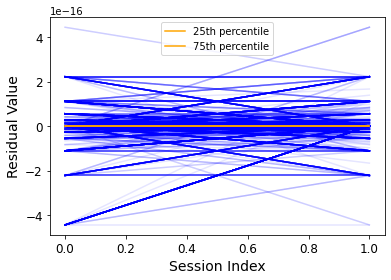

In [47]:
plot_edgewise_residual(residuals)
plt.xlabel('Session Index', fontsize=14)
plt.ylabel('Residual Value', fontsize=14)
plt.show()

#Retrieve confounds

### Retrieve scan time and day of week from the `scans.tsv` in the dataset repo

In [48]:
# Read the scans.tsv file
scans_df = pd.read_csv(dataset_path / "scans.tsv", sep='\t')
scans_df.drop(columns=["randstr"], inplace=True)

#Extract entities
# Each echo and magnitude and phase part of each functional scans are recorded on separate line, 
# but we have only one final image so keep only one of the identical acq_time
scans_df = scans_df.drop_duplicates(subset=["acq_time"])
scans_df = scans_df.assign(
    subject=scans_df["filename"].str.extract(r"sub-(\d+)/"),
    session=scans_df["filename"].str.extract(r"ses-(\w+)/"),
    modality=scans_df["filename"].str.split("/").str[2],
    task=scans_df["filename"].str.extract(r"task-(\w+)_"),
    pe_dir=scans_df["filename"].str.extract(r"dir-(\w+)_"),
)
# Keep only the magnitude part of functional scans and first echo
scans_df = scans_df[scans_df["modality"] == "func"]

# Create dataframe based on the list of files
files_df = pd.DataFrame(files, columns=['file_path'])
files_df = files_df.assign(
    subject=files_df["file_path"].str.extract(r"sub-(\d+)/"),
    session=files_df["file_path"].str.extract(r"ses-(\w+)/"),
    task=files_df["file_path"].str.extract(r"task-(\w+)_"),
)

#Pair filenames with acquisition time
confounds_df = pd.merge(
        scans_df, files_df, on=["subject", "session", "task"], how="inner"
    )
confounds_df.drop(columns=["file_path"], inplace=True)

# From the acq_time column, extract the day of week and time of day
confounds_df = confounds_df.assign(datetime = pd.to_datetime(confounds_df["acq_time"]))
confounds_df = confounds_df.assign(
    day_of_week = confounds_df['datetime'].dt.day_name(),
    time_of_day = confounds_df['datetime'].dt.round('H').dt.time
)
confounds_df.drop(columns=["datetime"], inplace=True)
print(confounds_df.head())


                                            filename  \
0  sub-001/ses-001/func/sub-001_ses-001_task-rsmo...   
1  sub-001/ses-003/func/sub-001_ses-003_task-rsmo...   

                     acq_time subject session modality     task pe_dir  \
0  2023-10-20T19:50:01.187500     001     001     func  rsmovie     LR   
1  2023-10-21T10:12:32.207500     001     003     func  rsmovie     LR   

  day_of_week time_of_day  
0      Friday    20:00:00  
1    Saturday    10:00:00  


### Retrieve coffee consumption from the issues in the GitHub repository of confound collection

In [49]:
""" # GitHub repository details
repo_owner = 'TheAxonLab'  # Replace with your GitHub username or org name
repo_name = 'hcph-mood-quest'
# Read token from token.txt
with open('/home/cprovins/token.txt', 'r') as file:
    token = file.read().strip()

# GitHub API headers
headers = {
    'Authorization': f'token {token}',
    'Accept': 'application/vnd.github.v3+json'
}

# Regular expression to match issue titles with the optional [BEFORE] tag and confounds of interest
issue_title_pattern = r'\[MOOD\](?:\[BEFORE\])? sub-001_ses-0\d{2}'
caffeine_2h_pattern = r'### Caffeine intake in the last 2h \(# cups\)\s+(\d+)'
caffeine_24h_pattern = r'### Caffeine intake in the last 24h \(# cups\)\s+(\d+)'

def get_confounds_in_issues():
    data = []
    page = 1

    while True:
        url = f'https://api.github.com/repos/{repo_owner}/{repo_name}/issues'
        params = {'state': 'all', 'per_page': 100, 'page': page}
        response = requests.get(url, headers=headers, params=params)
        issues = response.json()
        print(issues)
        
        # Stop if no more issues
        if not issues:
            break

        for issue in issues:
            title = issue['title']
            if re.search(issue_title_pattern, title):
                # Get the issue body
                issue_body = issue['body']

                # Extract scan time, and confounds of interest
                caffeine_2h = re.search(caffeine_2h_pattern, issue_body)
                caffeine_24h = re.search(caffeine_24h_pattern, issue_body)
                
                data.append({
                    'IssueTitle': title,
                    'CaffeineIntake2h': int(caffeine_2h.group(1)) if caffeine_2h else None,
                    'CaffeineIntake24h': int(caffeine_24h.group(1)) if caffeine_24h else None
                })
        
        page += 1

    return pd.DataFrame(data)

# Retrieve scan times
coffee_df = get_confounds_in_issues()

print(confounds_df) """

" # GitHub repository details\nrepo_owner = 'TheAxonLab'  # Replace with your GitHub username or org name\nrepo_name = 'hcph-mood-quest'\n# Read token from token.txt\nwith open('/home/cprovins/token.txt', 'r') as file:\n    token = file.read().strip()\n\n# GitHub API headers\nheaders = {\n    'Authorization': f'token {token}',\n    'Accept': 'application/vnd.github.v3+json'\n}\n\n# Regular expression to match issue titles with the optional [BEFORE] tag and confounds of interest\nissue_title_pattern = r'\\[MOOD\\](?:\\[BEFORE\\])? sub-001_ses-0\\d{2}'\ncaffeine_2h_pattern = r'### Caffeine intake in the last 2h \\(# cups\\)\\s+(\\d+)'\ncaffeine_24h_pattern = r'### Caffeine intake in the last 24h \\(# cups\\)\\s+(\\d+)'\n\ndef get_confounds_in_issues():\n    data = []\n    page = 1\n\n    while True:\n        url = f'https://api.github.com/repos/{repo_owner}/{repo_name}/issues'\n        params = {'state': 'all', 'per_page': 100, 'page': page}\n        response = requests.get(url, headers=

# Plot residuals grouped by bins of confound factor

In [50]:
# Merge residuals with confounds_df to get the time_of_day for each session
residuals_df = pd.DataFrame(residuals.T)
residuals_df = residuals_df.assign(
    session = files_df['session'],
)
residuals_df = pd.merge(residuals_df, confounds_df[['session', 'day_of_week', 'time_of_day','pe_dir']], on='session')
print(residuals_df.shape)
print(residuals_df.head())

(2, 2084)
              0    1             2    3    4    5    6    7    8  \
0 -4.440892e-16  0.0  2.775558e-17  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.000000e+00  0.0  0.000000e+00  0.0  0.0  0.0  0.0  0.0  0.0   

              9  ...          2074          2075          2076          2077  \
0  0.000000e+00  ... -4.440892e-16  1.387779e-17  0.000000e+00 -4.440892e-16   
1  1.387779e-17  ...  0.000000e+00  0.000000e+00  8.326673e-17  0.000000e+00   

           2078          2079  session  day_of_week  time_of_day  pe_dir  
0  2.775558e-17 -4.440892e-16      001       Friday     20:00:00      LR  
1  0.000000e+00  0.000000e+00      003     Saturday     10:00:00      LR  

[2 rows x 2084 columns]


# Test habituation significance

In [51]:
res = residuals_df.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
residuals_df = residuals_df.assign(
    variance = np.var(res, axis=0)
)
# Cast strings to type compatible with statistical models
residuals_df["session"] = pd.to_numeric(residuals_df["session"])
residuals_df["day_of_week"] = residuals_df["day_of_week"].astype("category")
residuals_df["time_of_day"] = residuals_df["time_of_day"].astype("category")
residuals_df["pe_dir"] = residuals_df["pe_dir"].astype("category")
print(residuals_df.head())

print("Here are the characteristics of the session with the highest variance:")
max_variance_row = residuals_df.loc[residuals_df['variance'].idxmax()]
print(max_variance_row)
residuals_wo_outlier_df = residuals_df.drop(max_variance_row.name)

              0    1             2    3    4    5    6    7    8  \
0 -4.440892e-16  0.0  2.775558e-17  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.000000e+00  0.0  0.000000e+00  0.0  0.0  0.0  0.0  0.0  0.0   

              9  ...          2075          2076          2077          2078  \
0  0.000000e+00  ...  1.387779e-17  0.000000e+00 -4.440892e-16  2.775558e-17   
1  1.387779e-17  ...  0.000000e+00  8.326673e-17  0.000000e+00  0.000000e+00   

           2079  session  day_of_week  time_of_day  pe_dir      variance  
0 -4.440892e-16        1       Friday     20:00:00      LR  1.127166e-32  
1  0.000000e+00        3     Saturday     10:00:00      LR  5.128343e-33  

[2 rows x 2085 columns]
Here are the characteristics of the session with the highest variance:
0                  -0.0
1                   0.0
2                   0.0
3                   0.0
4                   0.0
                 ...   
session               1
day_of_week      Friday
time_of_day    20:00:00
pe_dir           

In [52]:
# Fit the linear mixed effects model
X = sm.add_constant(residuals_df["session"]) # Adds the intercept term
y = residuals_df["variance"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               variance   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 21 May 2025   Prob (F-statistic):                nan
Time:                        16:25:34   Log-Likelihood:                 213.83
No. Observations:                   2   AIC:                            -423.7
Df Residuals:                       0   BIC:                            -426.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.434e-32        inf          0        n

/home/cprovins/.local/lib/python3.8/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 2 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/home/cprovins/.local/lib/python3.8/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/cprovins/.local/lib/python3.8/site-packages/statsmodels/regression/linear_model.py:1749: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/home/cprovins/.local/lib/python3.8/site-packages/statsmodels/regression/linear_model.py:1671: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [53]:
#Statistics excluding the outlier
# Fit the linear mixed effects model
X = sm.add_constant(residuals_wo_outlier_df["session"]) # Adds the intercept term
y = residuals_wo_outlier_df["variance"]
model_wo_outlier = sm.OLS(y, X).fit()
print(model_wo_outlier.summary())

ValueError: resids must contain at least 2 elements

In [ ]:
from statsmodels.stats.multitest import multipletests

# Assuming you have a list of p-values from multiple tests
p_values = [model.pvalues["session"], model_wo_outlier.pvalues["session"]]

# Apply Bonferroni correction
corrected_p_values = multipletests(p_values, method='bonferroni')[1]

print(f"Original p-values: {p_values}")
print(f"Corrected p-values: {corrected_p_values}")


Original p-values: [0.47009832877305624, 0.01911358084328313]
Corrected p-values: [0.94019666 0.03822716]


## Day of week

/home/cprovins/.local/lib/python3.8/site-packages/numpy/lib/polynomial.py:667: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


 ** On entry to DLASCL parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

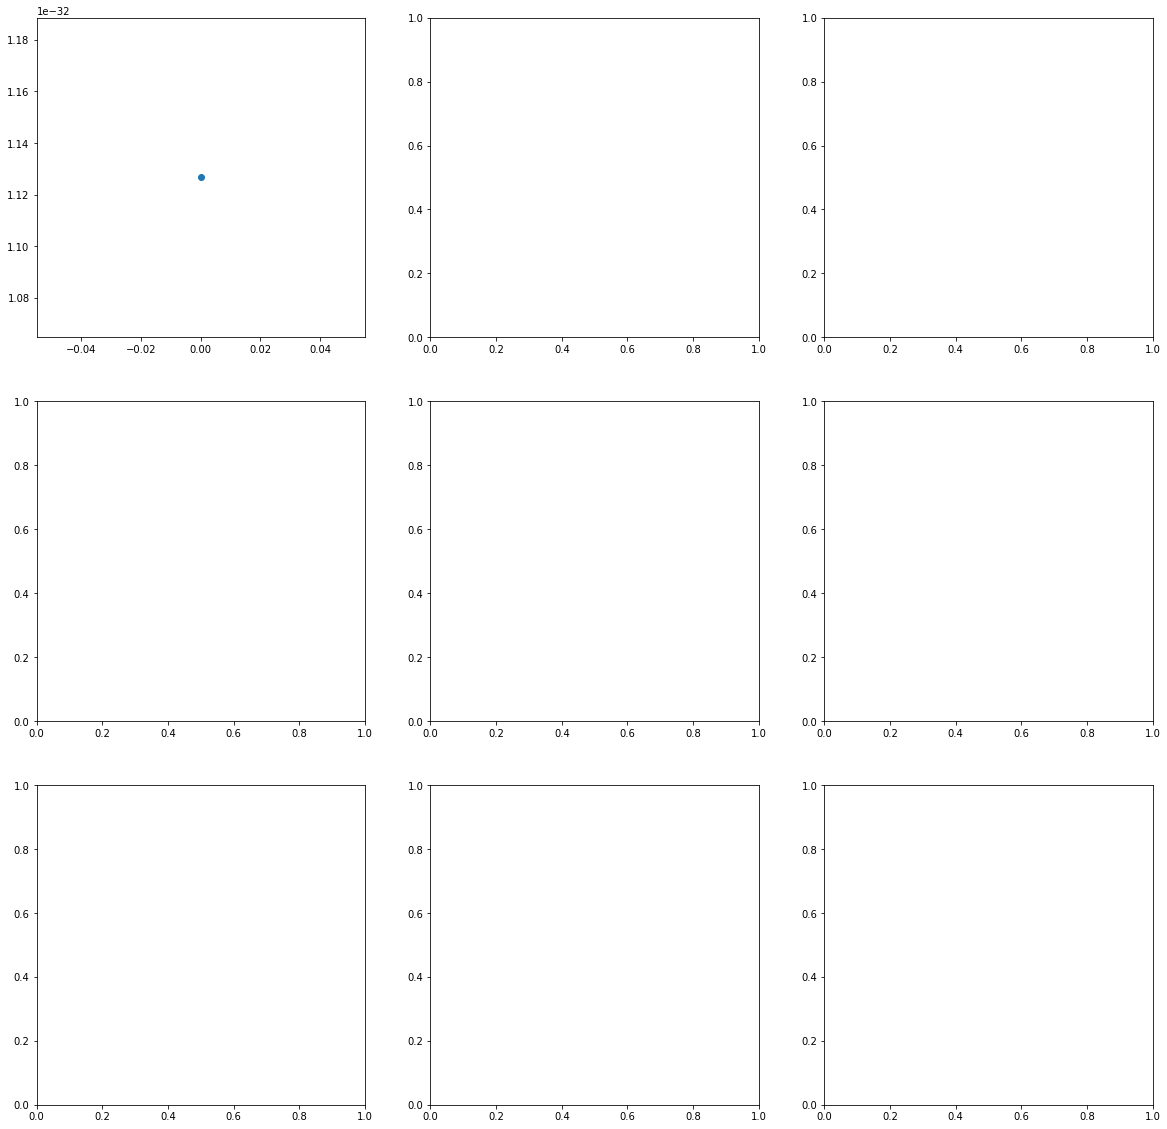

In [54]:
# Entities specific to this plot
entities = {'visualization': 'resvar', 'confound': 'day'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
min_res_var = 1000
max_res_var = 0
for i, (day_of_week, group) in enumerate(residuals_df.groupby('day_of_week')):
    plt.sca(axes[i // 3, i % 3])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    min_res_var, max_res_var = plot_res_variance(res, groupedby=day_of_week, min_res_var=min_res_var, max_res_var=max_res_var)

#Set same y-axis limits for all subplots
for ax in axes.flat:
    ax.set_ylim(min_res_var-0.01, max_res_var+0.01)
    
# Hide the last two subplots (axes[2, 1] and axes[2, 2])
axes[2, 1].axis('off')
axes[2, 2].axis('off')
fig.text(0.5, 0.08, 'Session Index', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Variance of Residuals', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

/usr/local/fsl/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


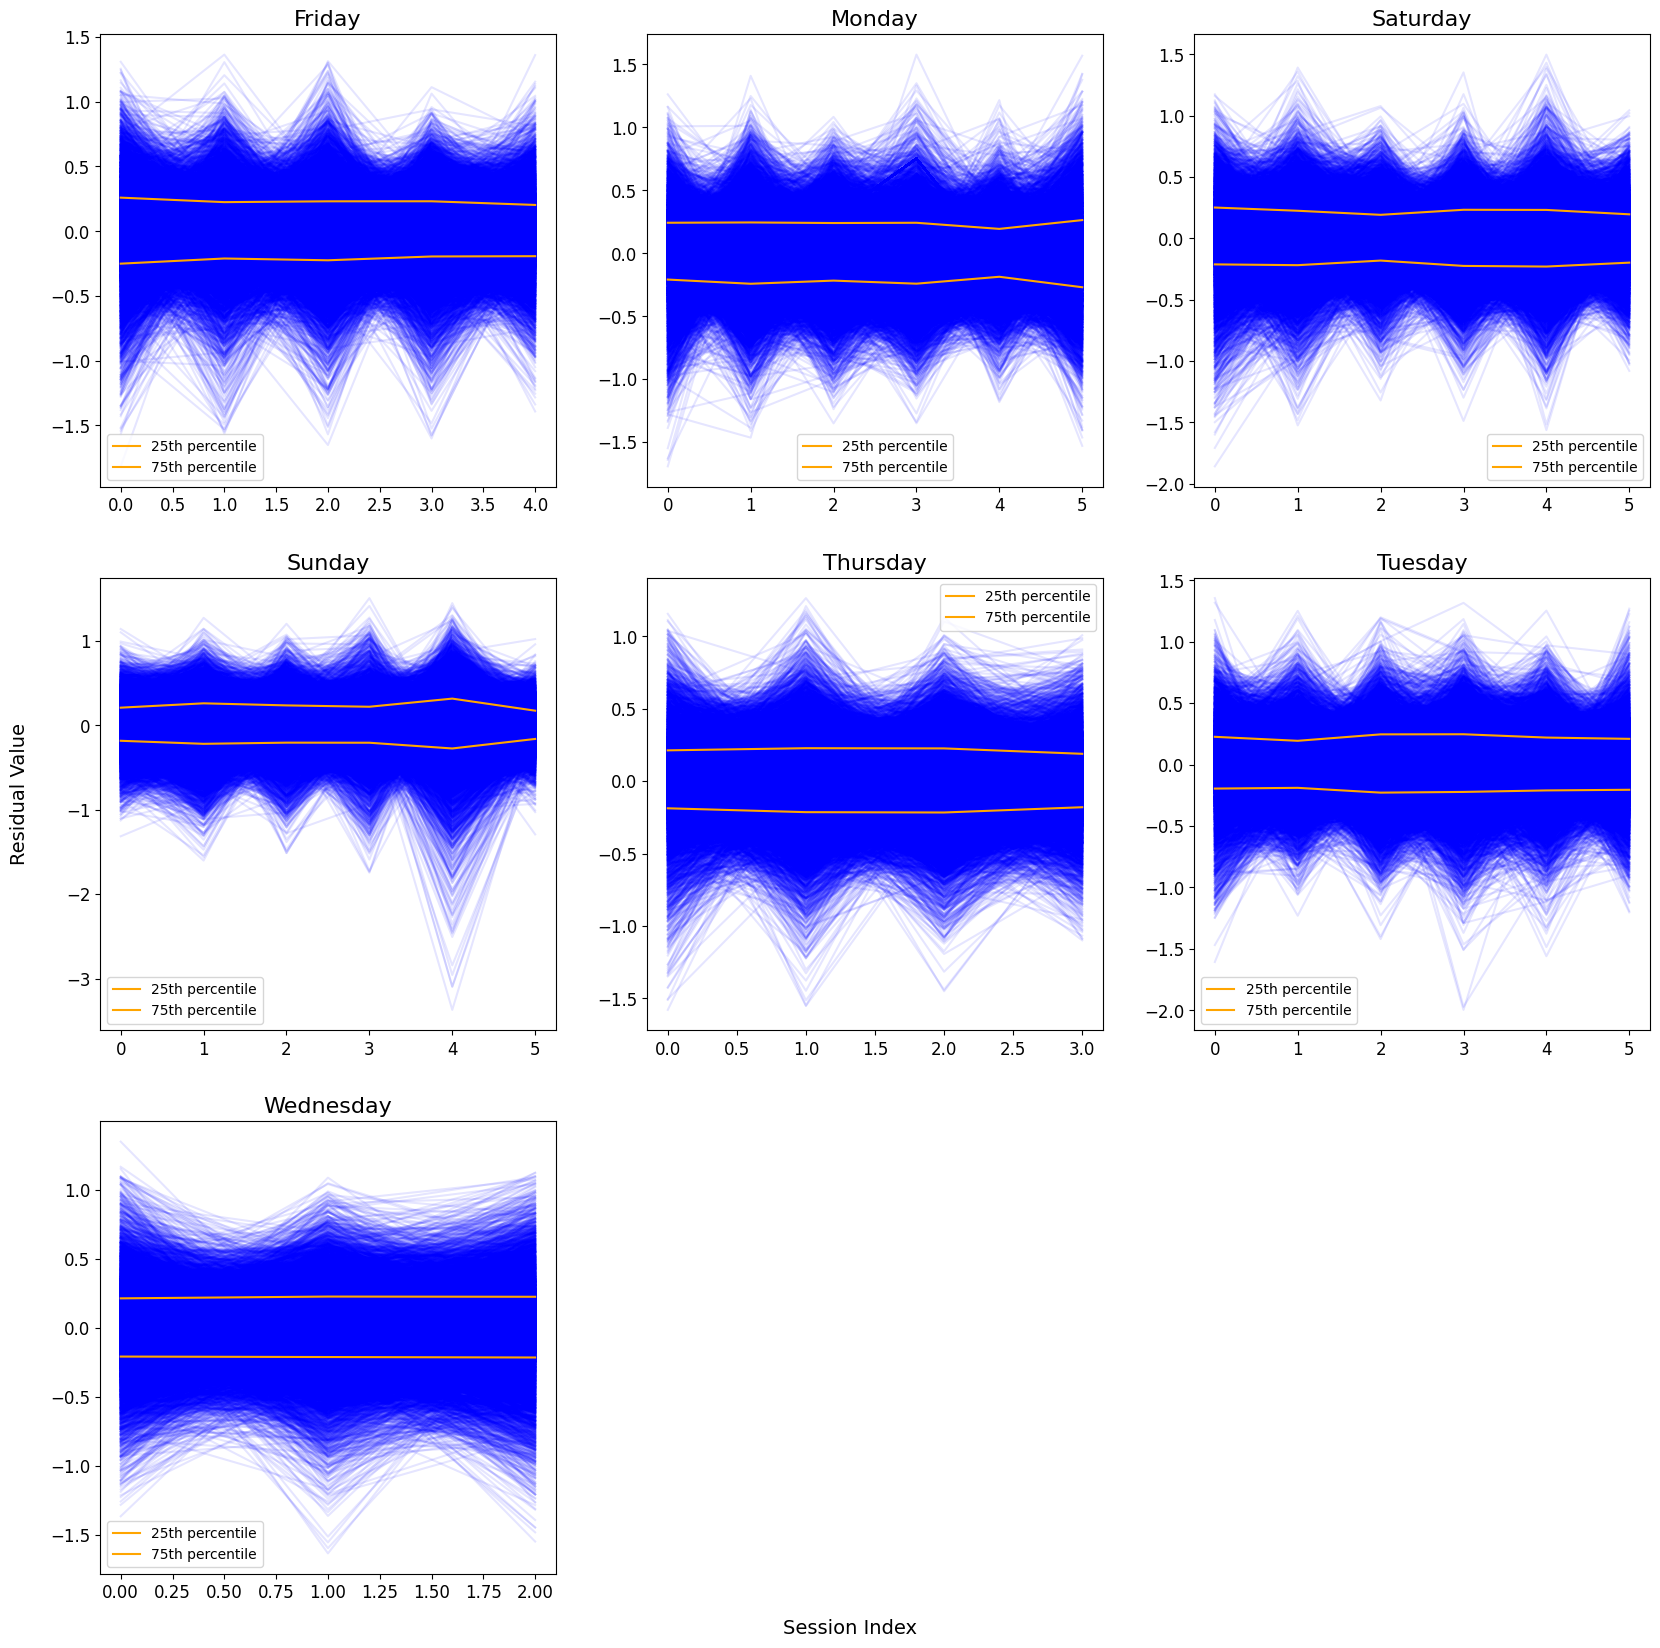

In [ ]:
# Entities specific to this plot
entities = {'visualization': 'edgewiseres', 'confound': 'day'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
for i, (day_of_week, group) in enumerate(residuals_df.groupby('day_of_week')):
    plt.sca(axes[i // 3, i % 3])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    plot_edgewise_residual(res, groupedby=day_of_week)
# Hide the last two subplots (axes[2, 1] and axes[2, 2])
axes[2, 1].axis('off')
axes[2, 2].axis('off')
fig.text(0.5, 0.08, 'Session Index', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Residual Value', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

## Time of day

Time of day: 09:00:00
(8257, 1)
Time of day: 10:00:00
(8257, 2)
Time of day: 11:00:00
(8257, 2)
Time of day: 12:00:00
(8257, 3)
Time of day: 18:00:00
(8257, 2)
Time of day: 19:00:00
(8257, 2)
Time of day: 20:00:00
(8257, 11)
Time of day: 21:00:00
(8257, 5)
Time of day: 22:00:00
(8257, 7)
Time of day: 23:00:00
(8257, 1)


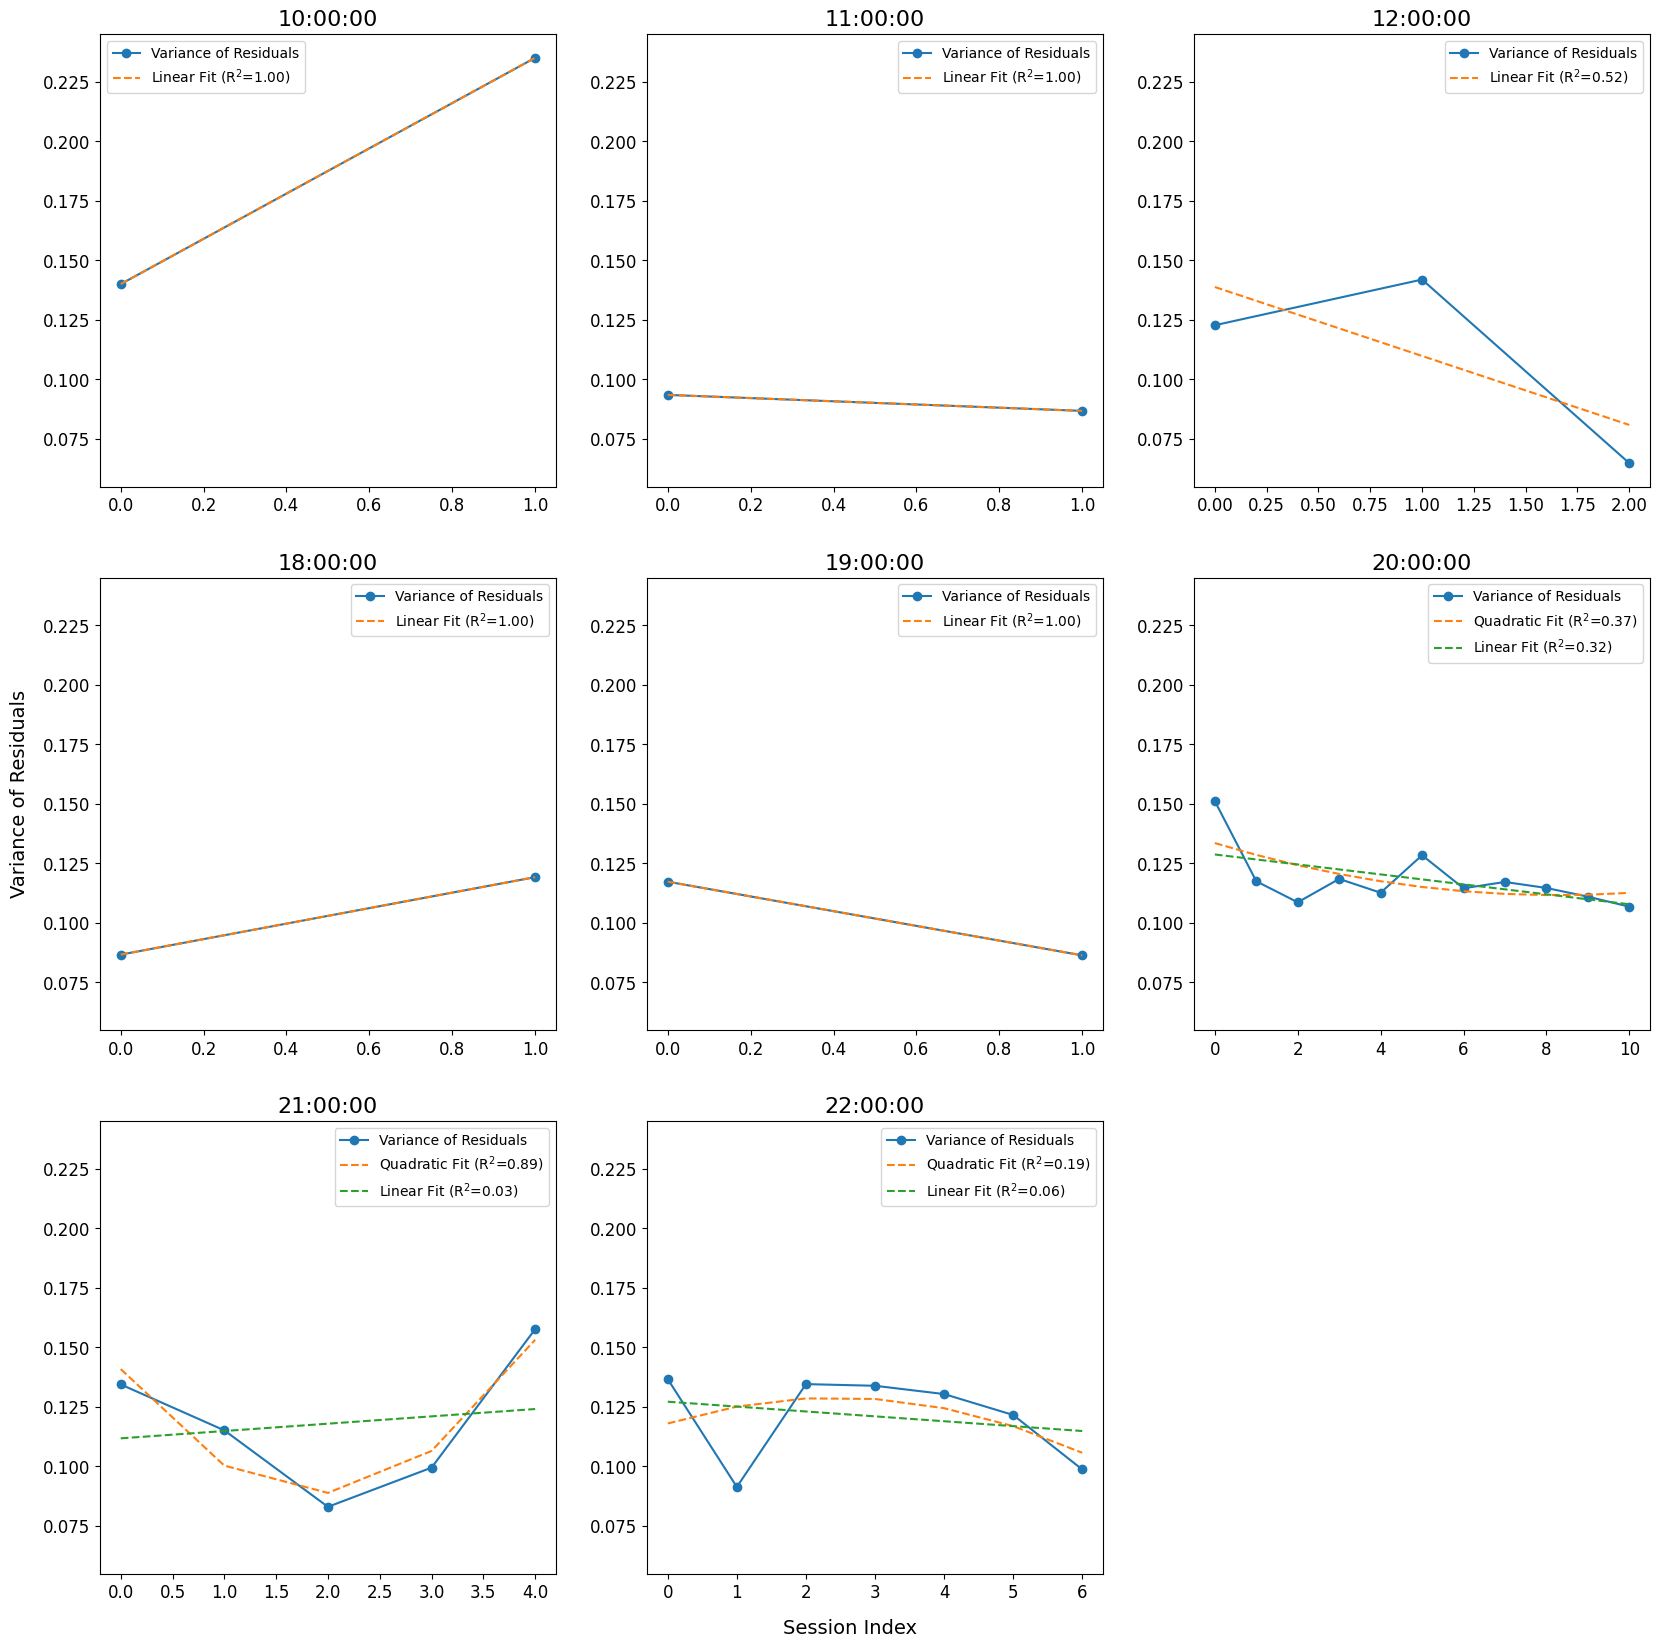

In [ ]:
# Entities specific to this plot
entities = {'visualization': 'resvar', 'confound': 'time'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
min_res_var = 1000
max_res_var = 0
i = 0
for time_of_day, group in residuals_df.groupby('time_of_day'):
    print("Time of day:", time_of_day)
    plt.sca(axes[i // 3, i % 3])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    print(res.shape)
    if res.shape[1] > 1:
        min_res_var, max_res_var = plot_res_variance(res, groupedby=time_of_day, min_res_var=min_res_var, max_res_var=max_res_var)
        i += 1

#Set same y-axis limits for all subplots
for ax in axes.flat:
    ax.set_ylim(min_res_var-0.01, max_res_var+0.01)

 # Hide the last axis
axes[2, 2].axis('off')
fig.text(0.5, 0.08, 'Session Index', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Variance of Residuals', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

Time of day: 09:00:00
(8257, 1)
Time of day: 10:00:00
(8257, 2)
Time of day: 11:00:00
(8257, 2)
Time of day: 12:00:00
(8257, 3)
Time of day: 18:00:00
(8257, 2)
Time of day: 19:00:00
(8257, 2)
Time of day: 20:00:00
(8257, 11)
Time of day: 21:00:00
(8257, 5)
Time of day: 22:00:00
(8257, 7)
Time of day: 23:00:00
(8257, 1)


/usr/local/fsl/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


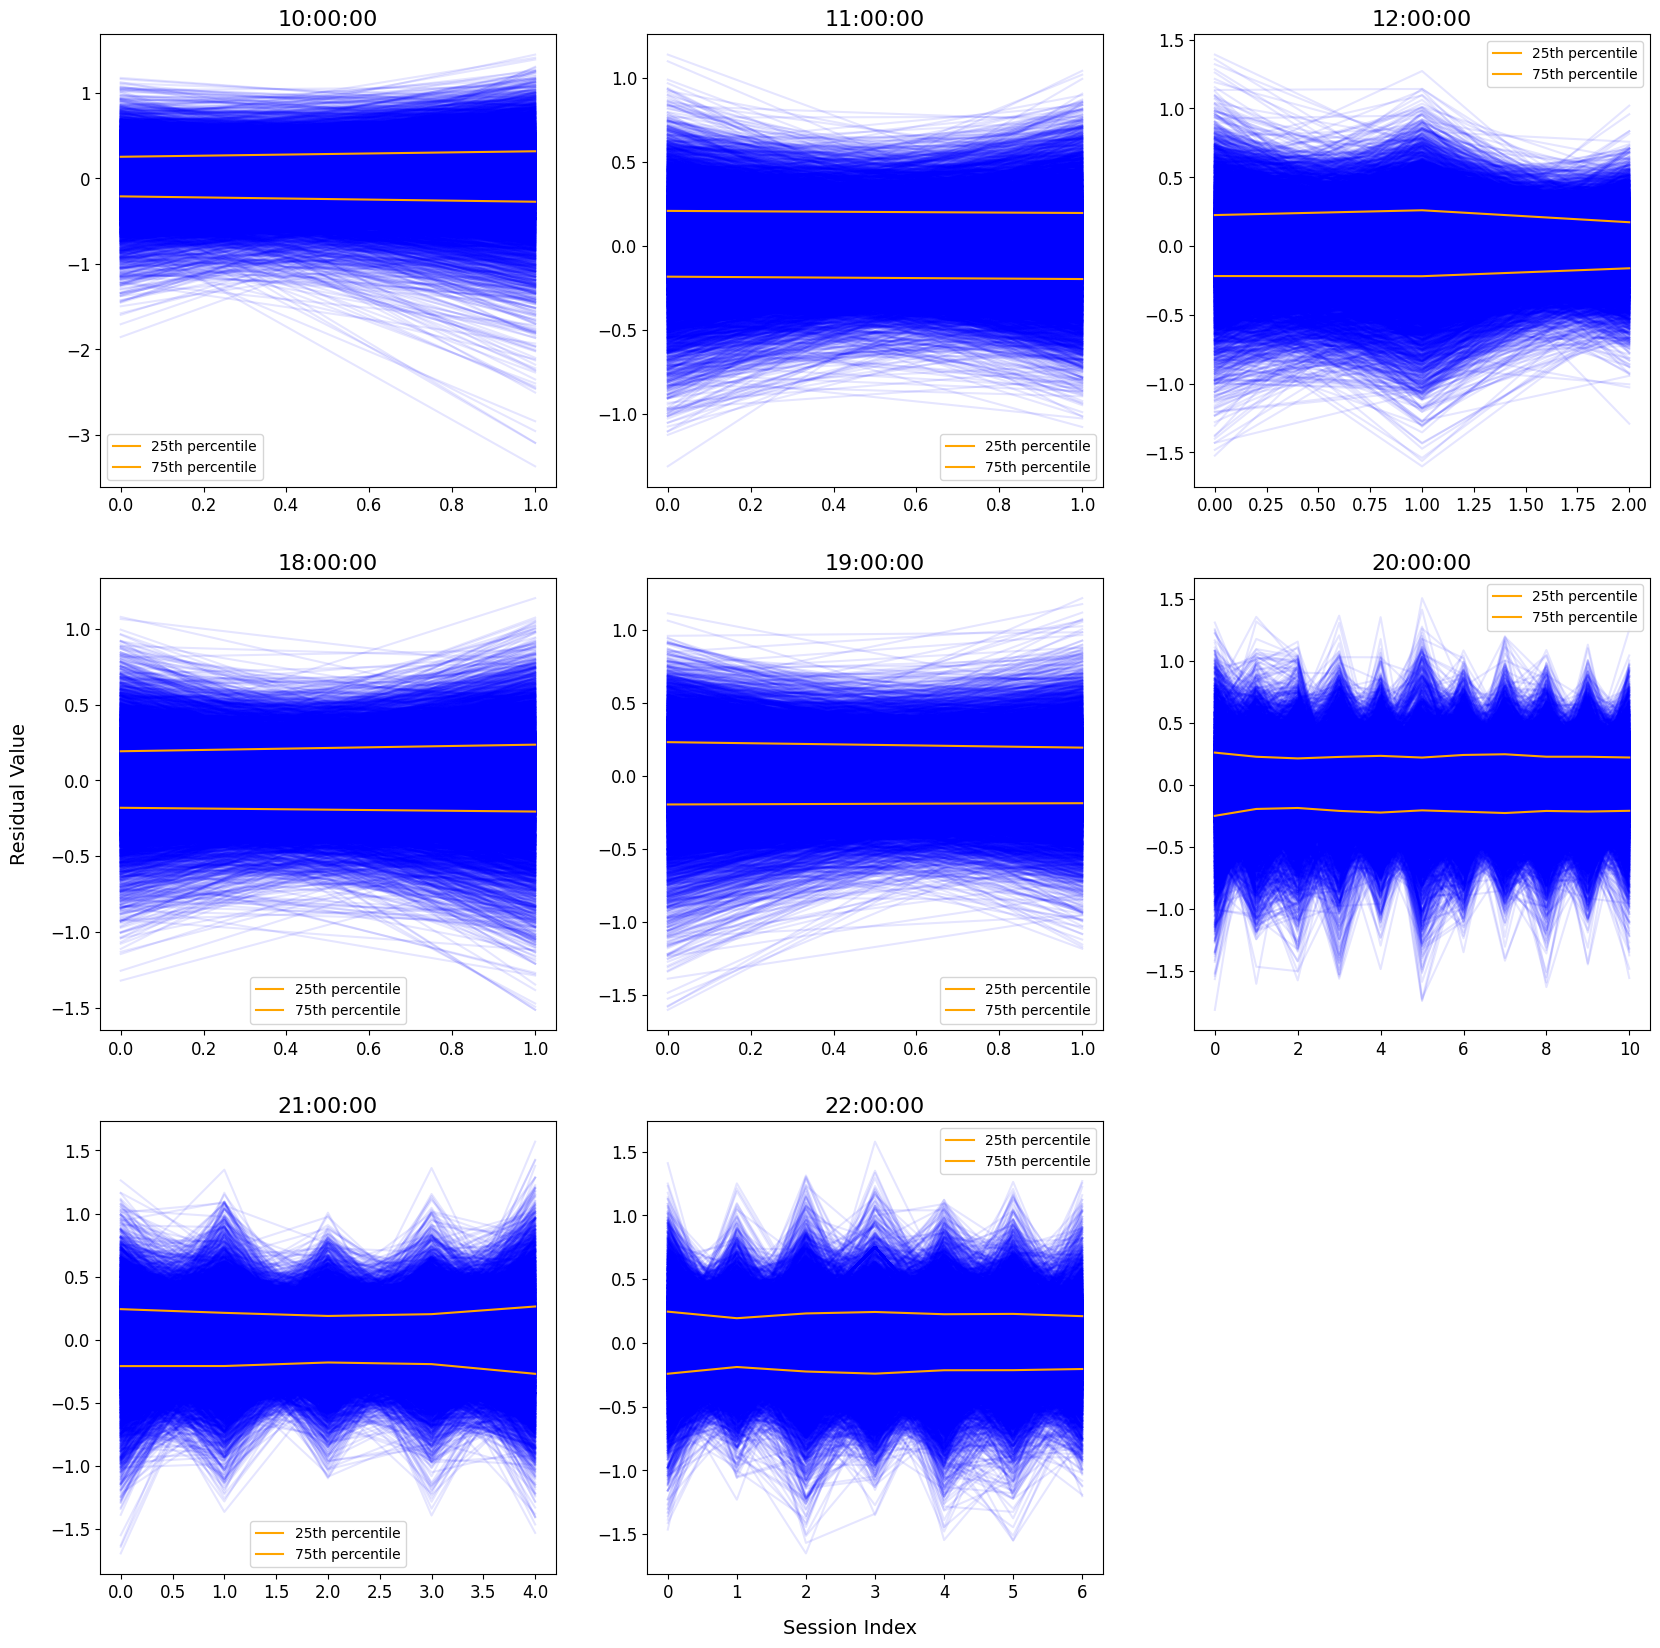

In [ ]:
# Entities specific to this plot
entities = {'visualization': 'edgewisevar', 'confound': 'time'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
min_res_var = 1000
max_res_var = 0
i = 0
for time_of_day, group in residuals_df.groupby('time_of_day'):
    print("Time of day:", time_of_day)
    plt.sca(axes[i // 3, i % 3])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    print(res.shape)
    if res.shape[1] > 1:
        plot_edgewise_residual(res, groupedby=time_of_day)
        i += 1

 # Hide the last axis
axes[2, 2].axis('off')
fig.text(0.5, 0.08, 'Session Index', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Residual Value', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

## Phase Encoding Direction

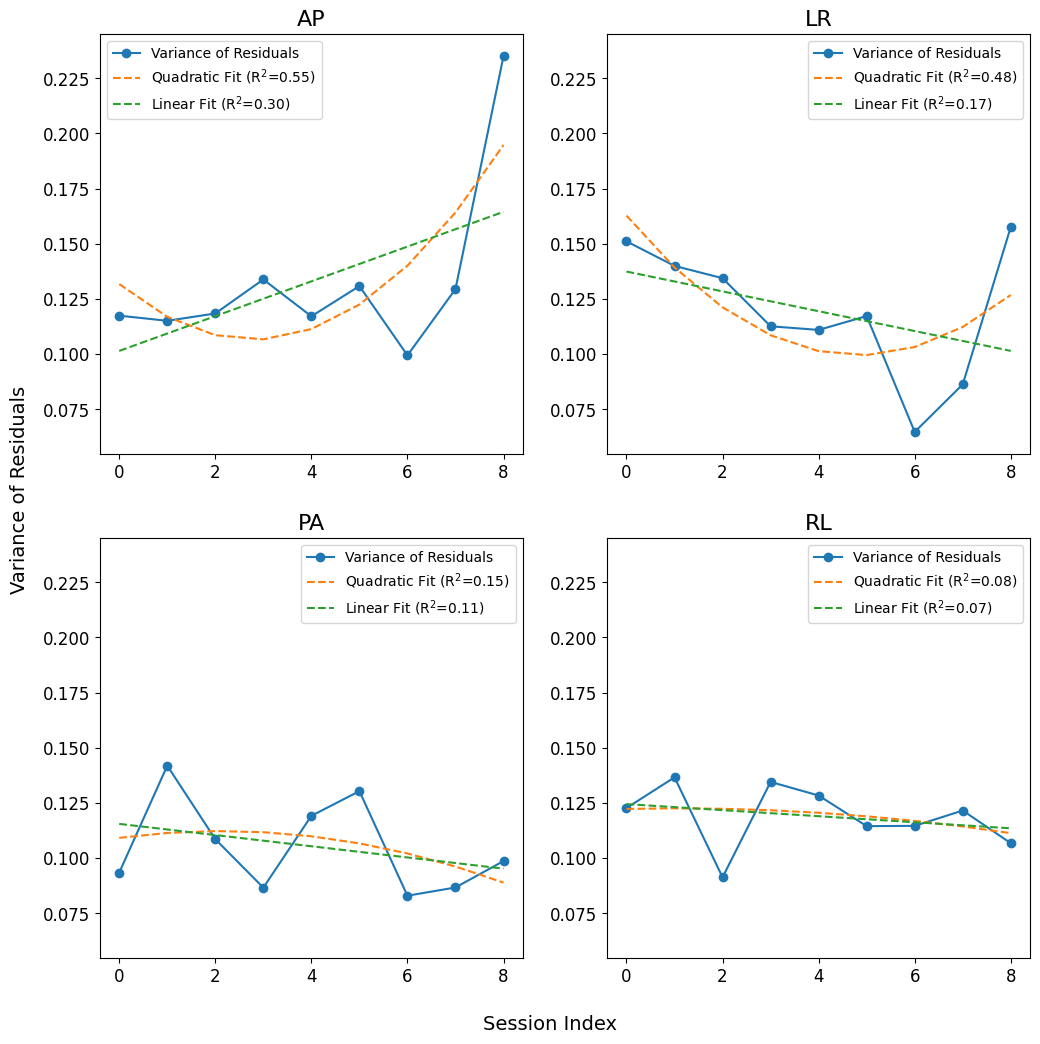

In [ ]:
# Entities specific to this plot
entities = {'visualization': 'resvar', 'confound': 'pe_dir'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
min_res_var = 1000
max_res_var = 0
for i, (pe_dir, group) in enumerate(residuals_df.groupby('pe_dir')):
    plt.sca(axes[i // 2, i % 2])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    min_res_var, max_res_var = plot_res_variance(res, groupedby=pe_dir, min_res_var=min_res_var, max_res_var=max_res_var)

#Set same y-axis limits for all subplots
for ax in axes.flat:
    ax.set_ylim(min_res_var-0.01, max_res_var+0.01)

fig.text(0.5, 0.05, 'Session Index', ha='center', fontsize=14)
fig.text(0.05, 0.5, 'Variance of Residuals', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()

/usr/local/fsl/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


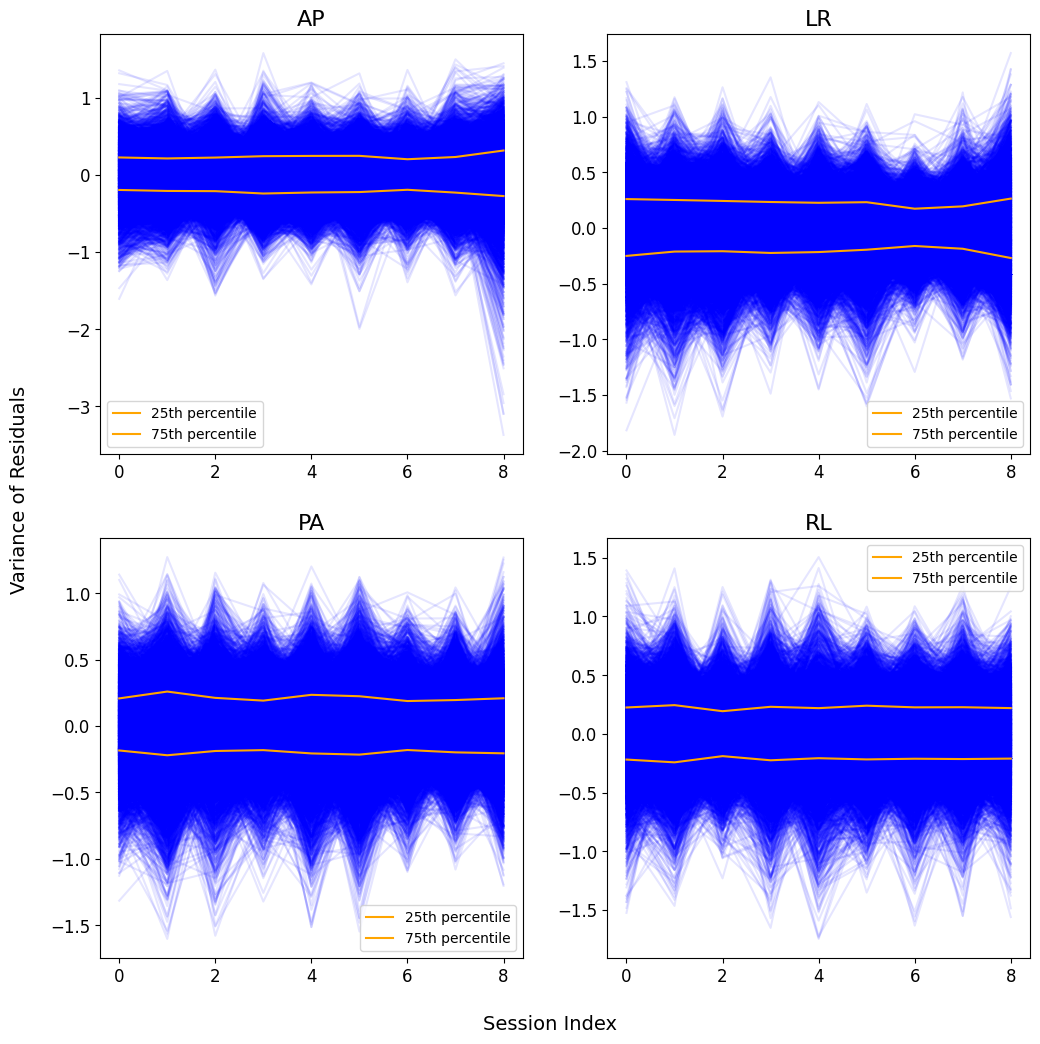

In [ ]:
# Entities specific to this plot
entities = {'visualization': 'edgewisevar', 'confound': 'pe_dir'}
entities.update(entities_base)

# Create figure with subplots for variance and edgewise residuals
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
min_res_var = 1000
max_res_var = 0
for i, (pe_dir, group) in enumerate(residuals_df.groupby('pe_dir')):
    plt.sca(axes[i // 2, i % 2])
    res = group.drop(columns=['session', 'day_of_week', 'time_of_day','pe_dir']).values.T
    plot_edgewise_residual(res, groupedby=pe_dir)

fig.text(0.5, 0.05, 'Session Index', ha='center', fontsize=14)
fig.text(0.05, 0.5, 'Variance of Residuals', va='center', rotation='vertical', fontsize=14)
save_path = save_layout.build_path(entities, validate=False)
plt.savefig(save_path)
plt.show()